In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime
import matplotlib.pyplot as plt

In [2]:
cwd = Path.cwd()
data_path = cwd / "data" / "export.csv"

In [3]:
data = pd.read_csv(
    filepath_or_buffer=str(data_path),
    encoding='latin-1',
    sep=",",
    thousands=',',
    na_values=['NA', 'N/A', 'null', 'NULL', '', ' ', 'None'],
)

In [4]:
data.tail()

,Date,Description,Category,Cost,Currency,Parv Chaturvedi,Shivam Verma,Divyansh Singh,AG,Nirnay Sinha,Kshitij Shekhar,Leo,Sakshar Daksh,Aditya Kumar,Rajiv Kumar,Kapil Kumar
715,2026-04-02,Chilli chicken,Groceries,450.0,INR,0.00,0.0,0.00,-112.50,0.0,-112.5,-112.50,450.00,-112.5,0.00,0.0
716,2026-04-03,Cold drink,Groceries,200.0,INR,-20.00,0.0,100.00,-20.00,-20.0,-20.0,-20.00,0.00,0.0,0.00,0.0
717,2026-04-03,AG paid Divyansh S.,Payment,40.0,INR,0.00,0.0,-40.00,40.00,0.0,0.0,0.00,0.00,0.0,0.00,0.0
718,2026-04-04,Paratha,Dining out,120.0,INR,120.00,-120.0,0.00,0.00,0.0,0.0,0.00,0.00,0.0,0.00,0.0
719,2026-04-04,Total balance,NaN,NaN,INR,449.66,-160.0,-291.33,-1316.51,70.0,-102.5,353.17,938.34,-112.5,-3.33,175.0


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Date             720 non-null    object 
 1   Description      720 non-null    object 
 2   Category         719 non-null    object 
 3   Cost             719 non-null    float64
 4   Currency         720 non-null    object 
 5   Parv Chaturvedi  720 non-null    float64
 6   Shivam Verma     720 non-null    float64
 7   Divyansh Singh   720 non-null    float64
 8   AG               720 non-null    float64
 9   Nirnay Sinha     720 non-null    float64
 10  Kshitij Shekhar  720 non-null    float64
 11  Leo              720 non-null    float64
 12  Sakshar Daksh    720 non-null    float64
 13  Aditya Kumar     720 non-null    float64
 14  Rajiv Kumar      720 non-null    float64
 15  Kapil Kumar      720 non-null    float64
dtypes: float64(12), object(4)
memory usage: 90.1+ KB


In [6]:
data["Cost"].sum().item()

122256.98000000001

In [7]:
data.iloc[data["Cost"].argmax().item()]

Date                       2025-10-23
Description        AG paid Sakshar D.
Category                      Payment
Cost                          3528.88
Currency                          INR
Parv Chaturvedi                   0.0
Shivam Verma                      0.0
Divyansh Singh                    0.0
AG                            3528.88
Nirnay Sinha                      0.0
Kshitij Shekhar                   0.0
Leo                               0.0
Sakshar Daksh                -3528.88
Aditya Kumar                      0.0
Rajiv Kumar                       0.0
Kapil Kumar                       0.0
Name: 230, dtype: object

In [8]:
data.iloc[data["Cost"].argmin().item()]

Date                        2025-09-08
Description        Sakshar D. paid Leo
Category                       Payment
Cost                              0.62
Currency                           INR
Parv Chaturvedi                    0.0
Shivam Verma                       0.0
Divyansh Singh                     0.0
AG                                 0.0
Nirnay Sinha                       0.0
Kshitij Shekhar                    0.0
Leo                              -0.62
Sakshar Daksh                     0.62
Aditya Kumar                       0.0
Rajiv Kumar                        0.0
Kapil Kumar                        0.0
Name: 33, dtype: object

In [9]:
data.columns

Index(['Date', 'Description', 'Category', 'Cost', 'Currency',
       'Parv Chaturvedi', 'Shivam Verma', 'Divyansh Singh', 'AG',
       'Nirnay Sinha', 'Kshitij Shekhar', 'Leo', 'Sakshar Daksh',
       'Aditya Kumar', 'Rajiv Kumar', 'Kapil Kumar'],
      dtype='object')

In [10]:
d = datetime.strptime(data["Date"].iloc[0], '%Y-%m-%d')

In [11]:
date_groupby = data.groupby("Date")['Cost'].sum().reset_index()

In [12]:
date_groupby["Date"] = date_groupby['Date'].apply(func=lambda x: datetime.strptime(x, "%Y-%m-%d"))

In [13]:
date_groupby

,Date,Cost
0,2025-08-31,1591.07
1,2025-09-01,319.29
2,2025-09-02,240.00
3,2025-09-03,90.00
4,2025-09-05,467.00
...,...,...
142,2026-03-29,130.42
143,2026-03-31,75.00
144,2026-04-02,450.00
145,2026-04-03,240.00


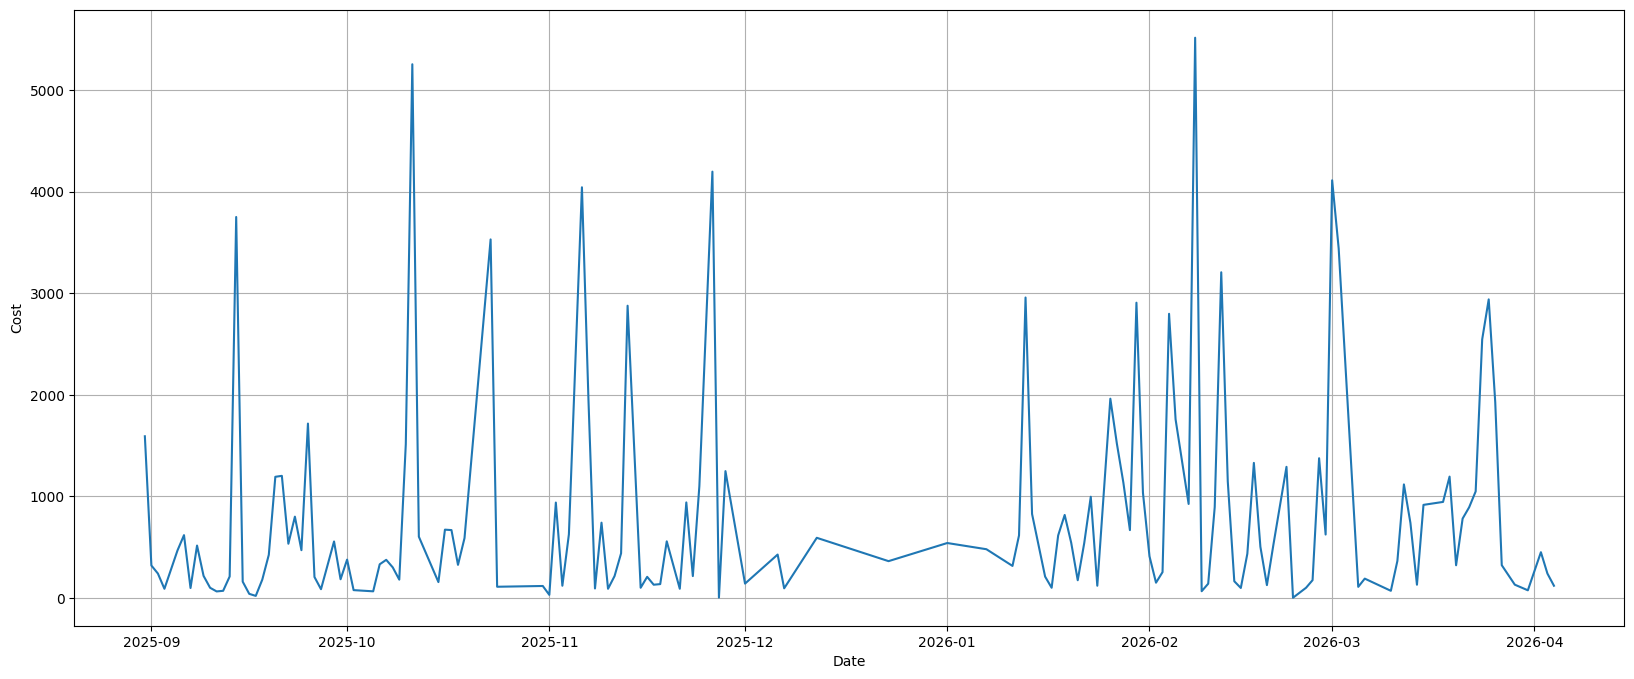

In [16]:
plt.figure(figsize=(20, 8))
plt.plot(date_groupby['Date'], date_groupby['Cost'])

plt.ylabel("Cost")
plt.xlabel("Date")
plt.grid()
plt.show()

In [17]:
date_groupby.iloc[date_groupby['Cost'].argmax()]

Date    2026-02-08 00:00:00
Cost                5514.22
Name: 103, dtype: object